# Named Entity Recognition with spaCy

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CDAC-lab/BUS3005-Resources/blob/main/NLP_2_Named_Entity_Recognition.ipynb)

Some words in a sentence refer to **real-world things with names** &mdash; people, companies, places, dates, amounts of money. These are called **named entities**, and pulling them out of text is called **Named Entity Recognition (NER)**.

NER is everywhere:

 * a news app tagging *which companies and people* an article mentions,
 * a CV scanner extracting *names, dates, and organisations*, and
 * a search engine understanding that *"Apple"* in *"Apple headquarters"* is a company, not a fruit.

In this notebook we'll use [**spaCy**](https://spacy.io/), a popular and beginner-friendly NLP library, to find entities in some example text, **highlight them inline** with colour, and list them in a **table**.

Click the **Play** icon beside each cell to run it, top to bottom.


First we install spaCy and download a small pre-trained English model. This takes under a minute in Colab.

In [1]:
#@title Install spaCy and download the English model
!pip install spacy --quiet
!python -m spacy download en_core_web_sm --quiet

import spacy
from spacy import displacy
import pandas as pd

# Load the small English model (already knows how to find entities)
nlp = spacy.load("en_core_web_sm")
print("spaCy model loaded and ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy model loaded and ready.


## Some example text

We'll analyse the short passage below. It deliberately contains several *different kinds* of entity &mdash; companies, people, places, dates, and money &mdash; so we can see how many spaCy detects.


In [2]:
text = (
    "Apple Inc. was founded by Steve Jobs and Steve Wozniak in Cupertino, "
    "California, in April 1976. Today the company is worth over $3 trillion, "
    "and Tim Cook has served as its CEO since 2011. In 2023, Apple opened a "
    "new store in London and hired thousands of employees across Europe."
)

doc = nlp(text)          # run spaCy's NLP pipeline on the text
print(text)

Apple Inc. was founded by Steve Jobs and Steve Wozniak in Cupertino, California, in April 1976. Today the company is worth over $3 trillion, and Tim Cook has served as its CEO since 2011. In 2023, Apple opened a new store in London and hired thousands of employees across Europe.


## Visualising entities inline

spaCy's `displacy` tool can render the text with every entity **highlighted and labelled** in place. This is the clearest way to *see* what NER does. Run the cell below.


In [3]:
displacy.render(doc, style="ent", jupyter=True)

Each highlighted span is an entity, and the tag beside it is the entity **type**. A few common types:

 * **PERSON** &mdash; people's names
 * **ORG** &mdash; companies, agencies, institutions
 * **GPE** &mdash; "geo-political entities": countries, cities, states
 * **DATE** &mdash; dates and periods
 * **MONEY** &mdash; monetary amounts

spaCy predicted all of these from the sentence structure and its training &mdash; we never gave it a list of company or city names.


## Entities in a table

Highlighting is great for reading, but for analysis we usually want the entities in a **structured table** we can sort, count, or export. Every entity spaCy finds has a `.text`, a `.label_` (its type), and a position in the document.


In [4]:
entities = []
for ent in doc.ents:
    entities.append({
        "entity": ent.text,
        "type": ent.label_,
        "meaning": spacy.explain(ent.label_),   # human-readable description
        "start_char": ent.start_char,
        "end_char": ent.end_char,
    })

entities_df = pd.DataFrame(entities)
entities_df

,entity,type,meaning,start_char,end_char
0,Apple Inc.,ORG,"Companies, agencies, institutions, etc.",0,10
1,Steve Jobs,PERSON,"People, including fictional",26,36
2,Steve Wozniak,PERSON,"People, including fictional",41,54
3,Cupertino,GPE,"Countries, cities, states",58,67
4,California,GPE,"Countries, cities, states",69,79
5,April 1976,DATE,Absolute or relative dates or periods,84,94
6,Today,DATE,Absolute or relative dates or periods,96,101
7,over $3 trillion,MONEY,"Monetary values, including unit",123,139
8,Tim Cook,PERSON,"People, including fictional",145,153
9,2011,DATE,Absolute or relative dates or periods,182,186


Now the entities are data. We could, for example, keep only the `ORG` rows to get every organisation mentioned, or count how often each type appears &mdash; which is exactly the next chart.


### How many of each entity type?

Counting entity types gives a quick profile of what a document is *about*. A text full of `PERSON` and `ORG` entities reads very differently from one full of `DATE` and `MONEY`.


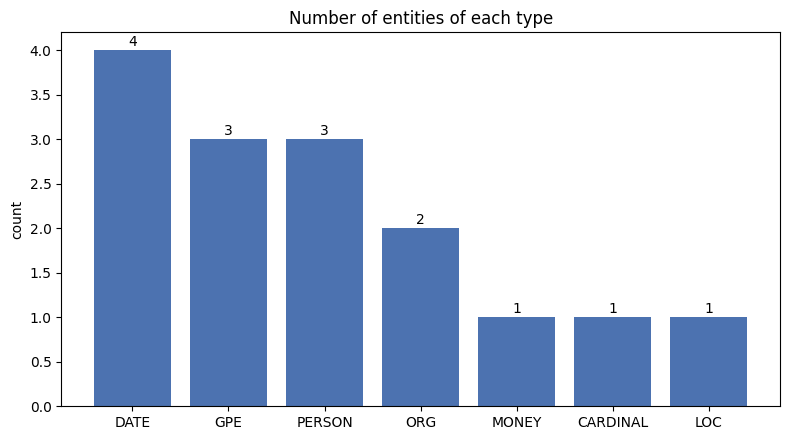

In [5]:
import matplotlib.pyplot as plt

type_counts = entities_df["type"].value_counts()

plt.figure(figsize=(8, 4.5))
plt.bar(type_counts.index, type_counts.values, color="#4C72B0")
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 0.05, str(v), ha="center")
plt.title("Number of entities of each type")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Try it yourself

Paste your own sentence or paragraph below &mdash; a news snippet, a bio, an email &mdash; and run **both** cells to see the highlights and the table for your own text.


In [6]:
my_text = "Elon Musk moved Tesla's headquarters to Austin, Texas, in 2021."  #@param {type:"string"}

my_doc = nlp(my_text)
displacy.render(my_doc, style="ent", jupyter=True)

In [7]:
pd.DataFrame(
    [{"entity": e.text, "type": e.label_, "meaning": spacy.explain(e.label_)}
     for e in my_doc.ents]
)

,entity,type,meaning
0,Elon Musk,PERSON,"People, including fictional"
1,Tesla,ORG,"Companies, agencies, institutions, etc."
2,Austin,GPE,"Countries, cities, states"
3,Texas,GPE,"Countries, cities, states"
4,2021,DATE,Absolute or relative dates or periods


## Where NER struggles

spaCy's small model is fast and accurate on everyday text, but NER is not magic:

 * **Ambiguity** &mdash; *"Washington"* could be a person, a city, or a state; the model has to guess from context.
 * **Unusual or new names** &mdash; brand-new company names or rare surnames may be missed.
 * **Domain shift** &mdash; a model trained on news text will do worse on medical notes or legal contracts, where a specialised model works better.
 * **Messy text** &mdash; missing capitalisation or punctuation hurts accuracy, since those are strong clues.

For higher accuracy you can use spaCy's larger models (`en_core_web_trf`), or fine-tune a model on text from your specific domain.


# Discussion points

 * Did spaCy miss any entity, or tag anything incorrectly, in the example text?
 * Why is `GPE` (geo-political entity) a more precise label than just "place"?
 * How could a company use the entities table &mdash; for example, from thousands of news articles?
 * NER extracts *who* and *where*, but not *relationships* (e.g. "Tim Cook works for Apple"). What would you need to capture those?


# Further reading

 * [**spaCy 101**](https://spacy.io/usage/spacy-101) &mdash; a friendly introduction to the whole library.
 * [**spaCy Named Entities**](https://spacy.io/usage/linguistic-features#named-entities) &mdash; the full list of entity types and how NER works.
 * [**displaCy visualiser**](https://spacy.io/usage/visualizers) &mdash; more ways to visualise language.

---
*This notebook uses spaCy's pre-trained `en_core_web_sm` model, simplified for teaching.*
